# CS 6220 — Homework 1: Iris Flower Classification

This notebook sets up a data mining pipeline using the Iris dataset. 
We build a scikit-learn `Pipeline` to classify iris flowers into species 
based on their sepal/petal measurements, split the data into train/test sets, 
train a classifier, and report accuracy.

In [1]:
# Import libraries
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Load the Iris Dataset

We use scikit-learn's built-in Iris dataset loader, which provides the same 
data as the UCI repository (sepal length/width, petal length/width, and species class).

In [2]:
# Load the Iris dataset
iris = load_iris(as_frame=True)
df = iris.frame
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Exploratory Scatterplot

A quick visualization of petal length vs. petal width, colored by species, 
similar to the plots on the Iris Wikipedia page.

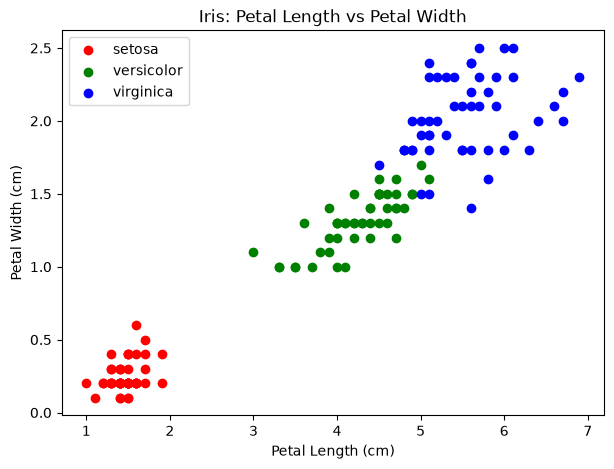

In [4]:
# Scatterplot: petal length vs petal width, colored by species
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}

plt.figure(figsize=(7, 5))
for species, color in colors.items():
    subset = df[df['species'] == species]
    plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'], 
                label=species, color=color)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris: Petal Length vs Petal Width')
plt.legend()
plt.show()

## Train/Test Split

We split the dataset into 80% training data and 20% test data.

In [5]:
# Features and target
X = df[iris.feature_names]
y = df['target']

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 120
Test samples: 30


## Build and Train the Pipeline

We use scikit-learn's `Pipeline` to chain feature scaling with a 
Logistic Regression classifier. We instrument the code with timers 
to measure training and testing time.

In [6]:
# Build the pipeline: scaling + logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=200))
])

# Train the pipeline, timing it
start_train = time.time()
pipeline.fit(X_train, y_train)
end_train = time.time()

training_time = end_train - start_train
print(f"Training time: {training_time:.4f} seconds")

Training time: 0.0625 seconds


## Evaluate on Test Data

We use the trained pipeline to predict on the test set, timing the 
prediction and reporting accuracy.

In [7]:
# Test the pipeline, timing it
start_test = time.time()
y_pred = pipeline.predict(X_test)
end_test = time.time()

testing_time = end_test - start_test
print(f"Testing time: {testing_time:.4f} seconds")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.4f}")

Testing time: 0.0017 seconds
Test accuracy: 1.0000


In [8]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
